In [1]:
SEED = 117  # 

# === Drive paths ===
DATA_2M_PATH     = "/content/drive/MyDrive/final_2M.parquet"
GOLD_TRAIN_PATH  = "/content/drive/MyDrive/gold_train.csv"
GOLD_TEST_PATH   = "/content/drive/MyDrive/gold_test.csv"

# === Output ===
OUTPUT_DIR   = "/content/drive/MyDrive/ate_phase2/output"
ATE_SAVE_DIR = f"{OUTPUT_DIR}/ate_phase2_seed{SEED}"

# === Model ===
BASE_MODEL = "roberta-base"
MAX_LENGTH = 192

# === Hyperparams ===
ATE_EPOCHS     = 3
ATE_BATCH_SIZE = 48
ATE_GRAD_ACCUM = 1
ATE_LR         = 1e-5
WARMUP_RATIO   = 0.1
WEIGHT_DECAY   = 0.01
VAL_RATIO      = 0.05

print(f"Seed: {SEED}")
print(f"Effective batch: {ATE_BATCH_SIZE * ATE_GRAD_ACCUM}")

Seed: 117
Effective batch: 48


In [2]:
!pip install -q transformers datasets accelerate seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
import os, gc, re, ast, warnings
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback,
    DataCollatorForTokenClassification,
)
from datasets import Dataset
from seqeval.metrics import f1_score as seq_f1, precision_score as seq_p, recall_score as seq_r

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [4]:
from google.colab import drive
drive.mount("/content/drive")

os.makedirs(ATE_SAVE_DIR, exist_ok=True)
for p in [DATA_2M_PATH, GOLD_TRAIN_PATH, GOLD_TEST_PATH]:
    assert os.path.exists(p), f"NOT FOUND: {p}"
print("All files found.")

Mounted at /content/drive
All files found.


## Step 1 — Data Preparation

In [5]:
def parse_aspects(val):
    if isinstance(val, list): return val
    if pd.isna(val) or str(val).strip() in ("", "[]", "nan"): return []
    s = str(val).strip()
    if "," in s:
        try: return ast.literal_eval(s)
        except: pass
    m = re.findall(r"'([^']*?)'", s)
    return m if m else []

def parse_confidences(val):
    if isinstance(val, list): return val
    if pd.isna(val) or str(val).strip() in ("", "[]", "nan"): return []
    s = str(val).strip()
    if "," in s:
        try: return ast.literal_eval(s)
        except: pass
    m = re.findall(r"[\d.]+", s)
    return [float(x) for x in m] if m else []

print("Loading 2M data...")
df_2m = pd.read_parquet(DATA_2M_PATH)
gold_train = pd.read_csv(GOLD_TRAIN_PATH)
gold_test  = pd.read_csv(GOLD_TEST_PATH)
print(f"2M: {df_2m.shape}, Gold train: {gold_train.shape}, Gold test: {gold_test.shape}")

CAT_MAP = {
    "Office_Products": "office_products",
    "Electronics_part1": "electronics_p1",
    "electronics_p2": "electronics_p2",
    "Software": "software",
}
df_2m["category_name"] = df_2m["category_name"].map(CAT_MAP).fillna("kindle_store")

for df in [df_2m, gold_train, gold_test]:
    df["aspects"]     = df["aspects"].apply(parse_aspects)
    df["confidences"] = df["confidences"].apply(parse_confidences)

print(f"2M categories: {df_2m['category_name'].value_counts().to_dict()}")

Loading 2M data...
2M: (2000000, 8), Gold train: (3200, 8), Gold test: (800, 8)
2M categories: {'office_products': 400000, 'software': 400000, 'kindle_store': 400000, 'electronics_p2': 400000, 'electronics_p1': 400000}


In [6]:
USE_COLS = ["parent_asin", "sentence_id", "sentence_text", "rating",
            "gate_confidence", "aspects", "confidences", "category_name"]

df_all = pd.concat([df_2m[USE_COLS], gold_train[USE_COLS]], ignore_index=True)
print(f"After merge: {len(df_all):,}")

# Remove gold_test leakage by sentence_text
test_texts = set(gold_test["sentence_text"].tolist())
before = len(df_all)
df_all = df_all[~df_all["sentence_text"].isin(test_texts)].reset_index(drop=True)
print(f"Removed {before - len(df_all)} gold_test leaks → {len(df_all):,} rows")

del df_2m
gc.collect()

After merge: 2,003,200
Removed 4329 gold_test leaks → 1,998,871 rows


209

In [7]:
train_idx, val_idx = train_test_split(
    np.arange(len(df_all)), test_size=VAL_RATIO,
    random_state=SEED, stratify=df_all["category_name"],
)
df_train = df_all.iloc[train_idx].reset_index(drop=True)
df_val   = df_all.iloc[val_idx].reset_index(drop=True)
print(f"Train: {len(df_train):,}  Val: {len(df_val):,}")

del df_all
gc.collect()

Train: 1,898,927  Val: 99,944


0

## Step 2 — Build BIO Dataset

In [8]:
ate_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, add_prefix_space=True)

LABEL2ID = {"O": 0, "B-ASP": 1, "I-ASP": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}


def create_bio_labels(sentence, aspects, tokenizer, max_length):
    enc = tokenizer(
        sentence, truncation=True, max_length=max_length,
        return_offsets_mapping=True, padding=False,
    )
    offsets = enc["offset_mapping"]
    labels = [-100] * len(offsets)

    for i, (s, e) in enumerate(offsets):
        if s == 0 and e == 0:
            labels[i] = -100
        else:
            labels[i] = LABEL2ID["O"]

    sentence_lower = sentence.lower()
    used_positions = set()

    for aspect in aspects:
        if not aspect:
            continue
        aspect_lower = aspect.lower().strip()
        start = sentence_lower.find(aspect_lower)
        if start == -1:
            continue
        end = start + len(aspect_lower)

        is_first = True
        for i, (ts, te) in enumerate(offsets):
            if ts == 0 and te == 0:
                continue
            if i in used_positions:
                continue
            if te <= start or ts >= end:
                continue
            if is_first:
                labels[i] = LABEL2ID["B-ASP"]
                is_first = False
            else:
                labels[i] = LABEL2ID["I-ASP"]
            used_positions.add(i)

    enc["labels"] = labels
    enc.pop("offset_mapping")
    return enc


# Sanity check
test_sent = "the sound is amazing and connected to my phone very smooth"
test_asp  = ["sound", "connection to my phone"]
test_enc  = create_bio_labels(test_sent, test_asp, ate_tokenizer, MAX_LENGTH)
tokens = ate_tokenizer.convert_ids_to_tokens(test_enc["input_ids"])
for t, l in zip(tokens, test_enc["labels"]):
    if l != -100:
        print(f"  {t:20s} → {ID2LABEL[l]}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

  Ġthe                 → O
  Ġsound               → B-ASP
  Ġis                  → O
  Ġamazing             → O
  Ġand                 → O
  Ġconnected           → O
  Ġto                  → O
  Ġmy                  → O
  Ġphone               → O
  Ġvery                → O
  Ġsmooth              → O


In [9]:
from tqdm.auto import tqdm

def build_ate_dataset(df, tokenizer, max_length):
    all_input_ids, all_attention_mask, all_labels = [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Building ATE data"):
        sentence = str(row["sentence_text"])
        aspects  = row["aspects"] if isinstance(row["aspects"], list) else []
        enc = create_bio_labels(sentence, aspects, tokenizer, max_length)
        all_input_ids.append(enc["input_ids"])
        all_attention_mask.append(enc["attention_mask"])
        all_labels.append(enc["labels"])
    return Dataset.from_dict({
        "input_ids": all_input_ids,
        "attention_mask": all_attention_mask,
        "labels": all_labels,
    })

print("Building ATE train dataset...")
ate_train_ds = build_ate_dataset(df_train, ate_tokenizer, MAX_LENGTH)
print(f"ATE train: {len(ate_train_ds)}")

print("Building ATE val dataset...")
ate_val_ds = build_ate_dataset(df_val, ate_tokenizer, MAX_LENGTH)
print(f"ATE val: {len(ate_val_ds)}")

del df_train, df_val
gc.collect()

Building ATE train dataset...


Building ATE data:   0%|          | 0/1898927 [00:00<?, ?it/s]

ATE train: 1898927
Building ATE val dataset...


Building ATE data:   0%|          | 0/99944 [00:00<?, ?it/s]

ATE val: 99944


74

## Step 3 — Train ATE Model

In [10]:
def compute_ate_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    true_labels, true_preds = [], []
    for pred_seq, label_seq in zip(preds, labels):
        t_labels, t_preds = [], []
        for p, l in zip(pred_seq, label_seq):
            if l == -100: continue
            t_labels.append(ID2LABEL[l])
            t_preds.append(ID2LABEL.get(p, "O"))
        true_labels.append(t_labels)
        true_preds.append(t_preds)
    return {
        "precision": seq_p(true_labels, true_preds, zero_division=0),
        "recall":    seq_r(true_labels, true_preds, zero_division=0),
        "f1":        seq_f1(true_labels, true_preds, zero_division=0),
    }

data_collator = DataCollatorForTokenClassification(ate_tokenizer, padding=True)

ate_model = AutoModelForTokenClassification.from_pretrained(
    BASE_MODEL, num_labels=3,
    id2label=ID2LABEL, label2id=LABEL2ID,
)

ate_trainer = Trainer(
    model=ate_model,
    args=TrainingArguments(
        output_dir=ATE_SAVE_DIR,
        num_train_epochs=ATE_EPOCHS,
        per_device_train_batch_size=ATE_BATCH_SIZE,
        per_device_eval_batch_size=64,
        gradient_accumulation_steps=ATE_GRAD_ACCUM,
        learning_rate=ATE_LR,
        lr_scheduler_type="linear",
        warmup_ratio=WARMUP_RATIO,
        weight_decay=WEIGHT_DECAY,
        fp16=True,
        logging_steps=200,
        eval_strategy="steps",
        eval_steps=2000,
        save_strategy="steps",
        save_steps=2000,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=2,
        seed=SEED,
        dataloader_num_workers=2,
        report_to="none",
    ),
    train_dataset=ate_train_ds,
    eval_dataset=ate_val_ds,
    data_collator=data_collator,
    compute_metrics=compute_ate_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)

print("Starting ATE training...")
ate_trainer.train(resume_from_checkpoint=True)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForTokenClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.bias                 | MISSING    | 
classifier.weight               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting ATE training...


There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=86000, training_loss=0.0022974968760512597, metrics={'train_runtime': 2448.4528, 'train_samples_per_second': 2326.686, 'train_steps_per_second': 48.473, 'total_flos': 1.464116291937464e+17, 'train_loss': 0.0022974968760512597, 'epoch': 2.173858092565911})

In [11]:
ate_trainer.save_model(ATE_SAVE_DIR)
ate_tokenizer.save_pretrained(ATE_SAVE_DIR)
print(f"ATE model saved to {ATE_SAVE_DIR}")

del ate_model, ate_trainer, ate_train_ds, ate_val_ds
gc.collect()
torch.cuda.empty_cache()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

ATE model saved to /content/drive/MyDrive/ate_phase2/output/ate_phase2_seed117


## Step 4 — Evaluate ATE on Gold Test

In [12]:
ate_tok   = AutoTokenizer.from_pretrained(ATE_SAVE_DIR, add_prefix_space=True)
ate_model = AutoModelForTokenClassification.from_pretrained(ATE_SAVE_DIR).to(device).eval()

test_sentences  = gold_test["sentence_text"].tolist()
gold_aspects_list = gold_test["aspects"].tolist()

@torch.no_grad()
def extract_aspects_with_confidence(sentences, tokenizer, model, batch_size=32):
    """
    span_confidence = mean(P(B-ASP) for first token, P(I-ASP) for continuation tokens)
    """
    all_aspects, all_confs = [], []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        enc = tokenizer(
            batch, padding=True, truncation=True,
            max_length=MAX_LENGTH, return_tensors="pt",
            return_offsets_mapping=True,
        )
        offsets = enc.pop("offset_mapping").numpy()
        enc = {k: v.to(device) for k, v in enc.items()}
        logits = model(**enc).logits
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()
        preds  = np.argmax(probs, axis=-1)

        for j in range(len(batch)):
            sentence = batch[j]
            aspects, confs = [], []
            span_start, span_end = None, None
            span_probs = []

            for k in range(preds.shape[1]):
                s, e = int(offsets[j][k][0]), int(offsets[j][k][1])
                if s == 0 and e == 0:
                    if span_start is not None:
                        text = sentence[span_start:span_end].strip()
                        if text:
                            aspects.append(text)
                            confs.append(float(np.mean(span_probs)))
                        span_start, span_end, span_probs = None, None, []
                    continue

                label = int(preds[j][k])
                if label == 1:  # B-ASP
                    if span_start is not None:
                        text = sentence[span_start:span_end].strip()
                        if text:
                            aspects.append(text)
                            confs.append(float(np.mean(span_probs)))
                    span_start, span_end = s, e
                    span_probs = [probs[j][k][1]]  # P(B-ASP)
                elif label == 2 and span_start is not None:  # I-ASP
                    span_end = e
                    span_probs.append(probs[j][k][2])  # P(I-ASP)
                else:  # O
                    if span_start is not None:
                        text = sentence[span_start:span_end].strip()
                        if text:
                            aspects.append(text)
                            confs.append(float(np.mean(span_probs)))
                        span_start, span_end, span_probs = None, None, []

            if span_start is not None:
                text = sentence[span_start:span_end].strip()
                if text:
                    aspects.append(text)
                    confs.append(float(np.mean(span_probs)))

            all_aspects.append(aspects)
            all_confs.append(confs)
    return all_aspects, all_confs

print("Running ATE inference on gold_test...")
pred_aspects, pred_confs = extract_aspects_with_confidence(
    test_sentences, ate_tok, ate_model
)
n_with = sum(1 for a in pred_aspects if a)
print(f"Done. Sentences with aspects: {n_with}/{len(pred_aspects)}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Running ATE inference on gold_test...
Done. Sentences with aspects: 485/800


In [13]:
def evaluate_ate_at_threshold(pred_aspects, pred_confs, gold_aspects, threshold):
    total_tp, total_fp, total_fn = 0, 0, 0
    for preds, confs, golds in zip(pred_aspects, pred_confs, gold_aspects):
        filtered = [p.lower().strip() for p, c in zip(preds, confs) if c >= threshold]
        gold_set = [g.lower().strip() for g in golds]
        matched_gold = set()
        tp = 0
        for pred in filtered:
            for gi, gold in enumerate(gold_set):
                if gi not in matched_gold and pred == gold:
                    tp += 1
                    matched_gold.add(gi)
                    break
            else:
                total_fp += 1
        total_tp += tp
        total_fn += len(gold_set) - len(matched_gold)

    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall    = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = total_tp / (total_tp + total_fp + total_fn) if (total_tp + total_fp + total_fn) > 0 else 0
    return {
        "threshold": threshold,
        "accuracy": round(accuracy, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "TP": total_tp, "FP": total_fp, "FN": total_fn,
    }

thresholds = [round(t * 0.1, 1) for t in range(10)]
ate_results = [evaluate_ate_at_threshold(pred_aspects, pred_confs, gold_aspects_list, t)
               for t in thresholds]

ate_bench = pd.DataFrame(ate_results)
print("=" * 70)
print("ATE MODEL — Benchmark on Gold Test (exact match)")
print("=" * 70)
print(ate_bench.to_string(index=False))

best_ate = ate_bench.loc[ate_bench["f1"].idxmax()]
print(f"\nBest threshold: {best_ate['threshold']} → F1={best_ate['f1']}")

ATE MODEL — Benchmark on Gold Test (exact match)
 threshold  accuracy  precision  recall     f1  TP  FP  FN
       0.0    0.4566     0.6540  0.6021 0.6270 395 209 261
       0.1    0.4566     0.6540  0.6021 0.6270 395 209 261
       0.2    0.4566     0.6540  0.6021 0.6270 395 209 261
       0.3    0.4566     0.6540  0.6021 0.6270 395 209 261
       0.4    0.4566     0.6540  0.6021 0.6270 395 209 261
       0.5    0.4572     0.6551  0.6021 0.6275 395 208 261
       0.6    0.4556     0.6707  0.5869 0.6260 385 189 271
       0.7    0.4476     0.6911  0.5595 0.6184 367 164 289
       0.8    0.4464     0.7210  0.5396 0.6173 354 137 302
       0.9    0.4316     0.7593  0.5000 0.6029 328 104 328

Best threshold: 0.5 → F1=0.6275


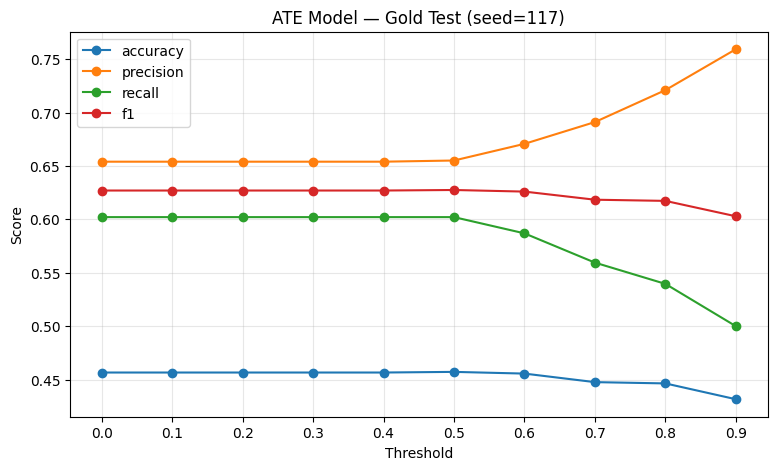

Report: /content/drive/MyDrive/ate_phase2/output/ate_benchmark_seed117.txt
Plot:   /content/drive/MyDrive/ate_phase2/output/ate_benchmark_seed117.png
Model:  /content/drive/MyDrive/ate_phase2/output/ate_phase2_seed117


In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
for metric in ["accuracy", "precision", "recall", "f1"]:
    ax.plot(ate_bench["threshold"], ate_bench[metric], marker="o", label=metric)
ax.set_title(f"ATE Model — Gold Test (seed={SEED})")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_xticks(thresholds)
ax.legend()
ax.grid(True, alpha=0.3)

plot_path = f"{OUTPUT_DIR}/ate_benchmark_seed{SEED}.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

report_path = f"{OUTPUT_DIR}/ate_benchmark_seed{SEED}.txt"
with open(report_path, "w") as f:
    f.write(f"ATE MODEL — Seed {SEED}\n")
    f.write("=" * 70 + "\n")
    f.write(ate_bench.to_string(index=False))
    f.write(f"\n\nBest threshold: {best_ate['threshold']} → F1={best_ate['f1']}\n")

print(f"Report: {report_path}")
print(f"Plot:   {plot_path}")
print(f"Model:  {ATE_SAVE_DIR}")